---
## 1. Install & Import Dependencies

In [20]:
!pip install -q xgboost imbalanced-learn shap plotly scikit-learn

In [21]:
import os, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shap

# Sklearn
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

# XGBoost
from xgboost import XGBClassifier

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.1)

SEV_MAP    = {0:'None', 1:'Mild', 2:'Moderate', 3:'Severe'}
SEV_ORDER  = ['None','Mild','Moderate','Severe']
SEV_COLORS = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
RANDOM_STATE = 42

print('All imports ready.')

All imports ready.


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
def find_file(root, filename):
    for dirpath, dirs, files in os.walk(root):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

DRIVE_ROOT  = '/content/drive/MyDrive'
PATH_FEATS  = find_file(DRIVE_ROOT, 'ddi_nigeria_features.csv')

print(f'ddi_nigeria_features.csv : {PATH_FEATS or "NOT FOUND"}')

# Manual override if needed:
# PATH_FEATS = '/content/drive/MyDrive/YOUR_FOLDER/ddi_nigeria_features.csv'

if PATH_FEATS is None:
    raise FileNotFoundError('Run Notebook 01 first to generate ddi_nigeria_features.csv')

SAVE_FOLDER = os.path.dirname(PATH_FEATS)
print(f'Save folder: {SAVE_FOLDER}')

ddi_nigeria_features.csv : /content/drive/MyDrive/DDI project /ddi_nigeria_features.csv
Save folder: /content/drive/MyDrive/DDI project 


In [24]:
df = pd.read_csv(PATH_FEATS)
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print(f'\nSeverity distribution:')
print(df['severity_label'].value_counts())
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

Dataset shape : (50, 37)
Columns       : ['drug_a', 'drug_b', 'class_a', 'class_b', 'severity', 'mw_a', 'mw_b', 'logp_a', 'logp_b', 'tpsa_a', 'tpsa_b', 'hbond_donors_a', 'hbond_donors_b', 'hbond_acceptors_a', 'hbond_acceptors_b', 'cyp3a4_inhibitor_a', 'cyp3a4_inducer_a', 'cyp2c9_inhibitor_a', 'cyp2c9_substrate_a', 'narrow_ti_a', 'protein_binding_a', 'half_life_a', 'cyp3a4_inhibitor_b', 'cyp3a4_inducer_b', 'cyp2c9_inhibitor_b', 'cyp2c9_substrate_b', 'narrow_ti_b', 'protein_binding_b', 'half_life_b', 'same_class', 'metabolic_conflict', 'inducer_substrate_conflict', 'both_narrow_ti', 'both_high_protein_binding', 'class_a_enc', 'class_b_enc', 'severity_label']

Severity distribution:
severity_label
Moderate    28
Severe      11
Mild         7
Name: count, dtype: int64

Missing values:
logp_a            1
logp_b            2
severity_label    4
dtype: int64


,drug_a,drug_b,class_a,class_b,severity,mw_a,mw_b,logp_a,logp_b,tpsa_a,tpsa_b,hbond_donors_a,hbond_donors_b,hbond_acceptors_a,hbond_acceptors_b,cyp3a4_inhibitor_a,cyp3a4_inducer_a,cyp2c9_inhibitor_a,cyp2c9_substrate_a,narrow_ti_a,protein_binding_a,half_life_a,cyp3a4_inhibitor_b,cyp3a4_inducer_b,cyp2c9_inhibitor_b,cyp2c9_substrate_b,narrow_ti_b,protein_binding_b,half_life_b,same_class,metabolic_conflict,inducer_substrate_conflict,both_narrow_ti,both_high_protein_binding,class_a_enc,class_b_enc,severity_label
0,rifampicin,efavirenz,Anti_TB,Antiretrovirals,2,822.9,315.67,4.9,4.0,220.0,38.3,6,1,15,5,0,1,0,0,0,80.0,3.0,1,1,0,0,0,99.0,52.0,0,0,0,0,0,1,8,Moderate
1,rifampicin,nevirapine,Anti_TB,Antiretrovirals,2,822.9,266.30,4.9,2.0,220.0,58.1,6,1,15,4,0,1,0,0,0,80.0,3.0,0,1,0,0,0,60.0,25.0,0,0,0,0,0,1,8,Moderate
2,rifampicin,lopinavir,Anti_TB,Antiretrovirals,3,822.9,628.80,4.9,5.9,220.0,120.0,6,4,15,5,0,1,0,0,0,80.0,3.0,0,0,0,0,0,99.0,6.0,0,0,1,0,0,1,8,Severe
3,rifampicin,dolutegravir,Anti_TB,Antiretrovirals,2,822.9,419.40,4.9,2.4,220.0,99.2,6,2,15,8,0,1,0,0,0,80.0,3.0,0,0,0,0,0,99.0,14.0,0,0,1,0,0,1,8,Moderate
4,rifampicin,warfarin,Anti_TB,Anticoagulants,3,822.9,308.30,4.9,2.7,220.0,63.6,6,1,15,4,0,1,0,0,0,80.0,3.0,0,0,0,1,1,99.0,40.0,0,0,0,0,0,1,3,Severe


---
## 3. Preprocessing & Class Imbalance Handling

Steps:
1. Select numeric feature columns
2. Impute missing values (median)
3. Scale features (StandardScaler) for Logistic Regression
4. Apply **SMOTE** to oversample minority classes
5. Stratified train/test split (80/20)

In [25]:
# Feature columns (all numeric — drop identity & label cols)
DROP_COLS = ['drug_a','drug_b','class_a','class_b','severity_label',
             'side_effect_name','source','Drug1_ID','Drug2_ID','Drug1','Drug2','Y']

FEATURE_COLS = [c for c in df.columns
                if c not in DROP_COLS + ['severity','class_a_enc','class_b_enc']
                and df[c].dtype in ['float64','int64','float32','int32']]

# Include encoded class columns as features
for enc_col in ['class_a_enc','class_b_enc']:
    if enc_col in df.columns and enc_col not in FEATURE_COLS:
        FEATURE_COLS.append(enc_col)

TARGET_COL = 'severity'

print(f'Feature columns ({len(FEATURE_COLS)}):')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {i+1:2d}. {col}')

Feature columns (31):
   1. mw_a
   2. mw_b
   3. logp_a
   4. logp_b
   5. tpsa_a
   6. tpsa_b
   7. hbond_donors_a
   8. hbond_donors_b
   9. hbond_acceptors_a
  10. hbond_acceptors_b
  11. cyp3a4_inhibitor_a
  12. cyp3a4_inducer_a
  13. cyp2c9_inhibitor_a
  14. cyp2c9_substrate_a
  15. narrow_ti_a
  16. protein_binding_a
  17. half_life_a
  18. cyp3a4_inhibitor_b
  19. cyp3a4_inducer_b
  20. cyp2c9_inhibitor_b
  21. cyp2c9_substrate_b
  22. narrow_ti_b
  23. protein_binding_b
  24. half_life_b
  25. same_class
  26. metabolic_conflict
  27. inducer_substrate_conflict
  28. both_narrow_ti
  29. both_high_protein_binding
  30. class_a_enc
  31. class_b_enc


In [26]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imp   = pd.DataFrame(imputer.fit_transform(X), columns=FEATURE_COLS)

print(f'X shape : {X_imp.shape}')
print(f'y shape : {y.shape}')
print(f'\nClass distribution before SMOTE:')
for cls, name in SEV_MAP.items():
    n = (y == cls).sum()
    print(f'  Class {cls} ({name:10s}): {n:5,}  {chr(9608)*int(n/len(y)*40)}')

X shape : (50, 31)
y shape : (50,)

Class distribution before SMOTE:
  Class 0 (None      ):     4  ███
  Class 1 (Mild      ):     7  █████
  Class 2 (Moderate  ):    28  ██████████████████████
  Class 3 (Severe    ):    11  ████████


In [27]:
# Stratified train/test split BEFORE SMOTE
# SMOTE is applied to training data only — test set stays real distribution
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_imp, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train set : {X_train_raw.shape[0]:,} samples')
print(f'Test set  : {X_test.shape[0]:,} samples')
print(f'\nClass split in train:')
for cls, name in SEV_MAP.items():
    n = (y_train_raw == cls).sum()
    print(f'  {name:10s}: {n:5,}')

Train set : 40 samples
Test set  : 10 samples

Class split in train:
  None      :     3
  Mild      :     6
  Moderate  :    22
  Severe    :     9


In [28]:
# Apply SMOTE to training data only
# k_neighbors=min(5, min_class_count-1) avoids error when minority class is tiny
min_class_count = y_train_raw.value_counts().min()
k_neighbors     = min(5, min_class_count - 1)
print(f'Smallest class in train: {min_class_count} samples')
print(f'SMOTE k_neighbors      : {k_neighbors}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print(f'\nAfter SMOTE:')
print(f'  Train size: {X_train.shape[0]:,} samples')
for cls, name in SEV_MAP.items():
    n = (y_train == cls).sum()
    print(f'  {name:10s}: {n:5,}  {chr(9608)*int(n/len(y_train)*40)}')

# Scale for Logistic Regression
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\nPreprocessing complete.')

Smallest class in train: 3 samples
SMOTE k_neighbors      : 2

After SMOTE:
  Train size: 88 samples
  None      :    22  ██████████
  Mild      :    22  ██████████
  Moderate  :    22  ██████████
  Severe    :    22  ██████████

Preprocessing complete.


In [29]:
print('Training Logistic Regression...')
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_s, y_train)

lr_preds      = lr_model.predict(X_test_s)
lr_proba      = lr_model.predict_proba(X_test_s)
lr_f1         = f1_score(y_test, lr_preds, average='macro')
lr_auc        = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3]),
                               lr_proba, multi_class='ovr', average='macro')

print(f'\nLogistic Regression Results:')
print(f'  Macro F1  : {lr_f1:.4f}')
print(f'  ROC-AUC   : {lr_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, lr_preds,
      target_names=SEV_ORDER, digits=4))

Training Logistic Regression...

Logistic Regression Results:
  Macro F1  : 0.1818
  ROC-AUC   : 0.6146

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.8000    0.6667    0.7273         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.4000        10
   macro avg     0.2000    0.1667    0.1818        10
weighted avg     0.4800    0.4000    0.4364        10



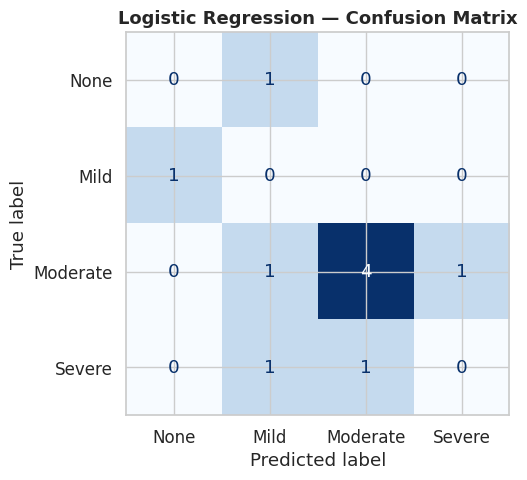

In [30]:
# Confusion matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(7,5))
cm_lr = confusion_matrix(y_test, lr_preds)
ConfusionMatrixDisplay(cm_lr, display_labels=SEV_ORDER).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)
rf_f1    = f1_score(y_test, rf_preds, average='macro')
rf_auc   = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3]),
                          rf_proba, multi_class='ovr', average='macro')

print(f'\nRandom Forest Results:')
print(f'  Macro F1  : {rf_f1:.4f}')
print(f'  ROC-AUC   : {rf_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, rf_preds,
      target_names=SEV_ORDER, digits=4))

Training Random Forest...

Random Forest Results:
  Macro F1  : 0.1250
  ROC-AUC   : 0.3108

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.5000    0.5000    0.5000         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.3000        10
   macro avg     0.1250    0.1250    0.1250        10
weighted avg     0.3000    0.3000    0.3000        10



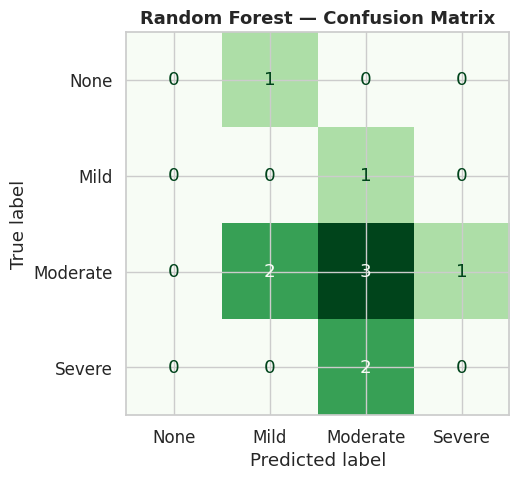

In [32]:
# RF Confusion matrix
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, rf_preds),
    display_labels=SEV_ORDER).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

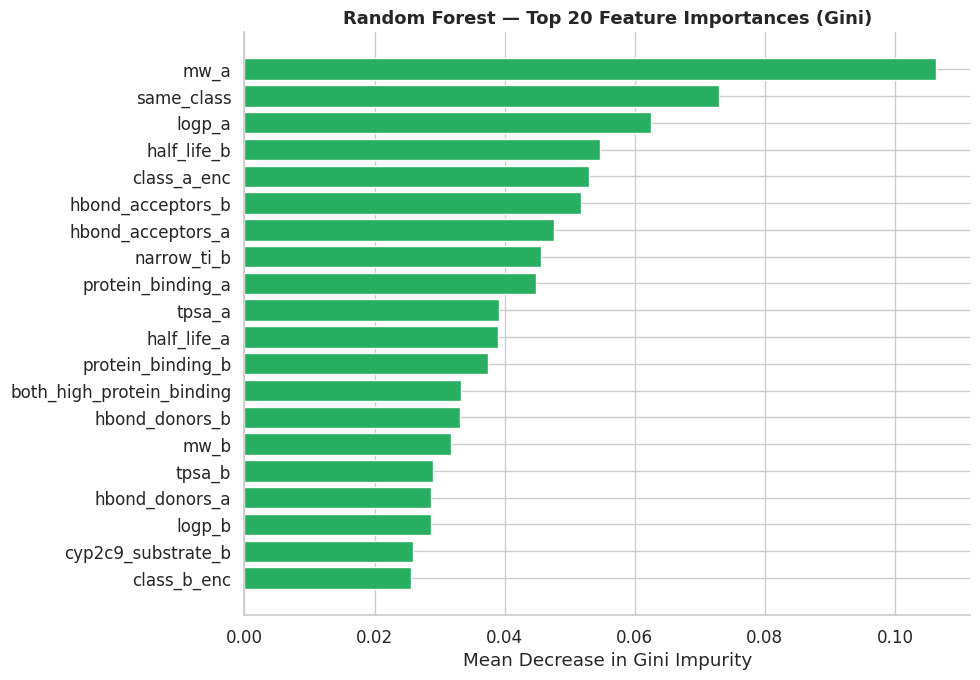

In [33]:
# Random Forest Feature Importance (top 20)
fi = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
fi = fi.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10,7))
bars = ax.barh(fi.index, fi.values, color='#27ae60', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances (Gini)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Compute class weights for XGBoost sample_weight
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Quick baseline XGBoost to confirm it runs
print('Training XGBoost baseline...')
xgb_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_base.fit(X_train, y_train, sample_weight=sample_weights)
base_preds = xgb_base.predict(X_test)
base_f1    = f1_score(y_test, base_preds, average='macro')
print(f'XGBoost baseline Macro F1: {base_f1:.4f}')

Training XGBoost baseline...
XGBoost baseline Macro F1: 0.0909


In [35]:
# GridSearchCV hyperparameter tuning
# Note: reduce n_estimators range if runtime is too long on CPU
print('Running GridSearchCV (this may take 5-10 mins on CPU)...')
print('Tip: Set n_jobs=-1 to use all cores.\n')

param_grid = {
    'n_estimators'    : [200, 400],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.7, 0.9],
}

xgb_cv = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = xgb_cv,
    param_grid = param_grid,
    scoring    = 'f1_macro',
    cv         = skf,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

print(f'\nBest parameters  : {grid_search.best_params_}')
print(f'Best CV F1 macro : {grid_search.best_score_:.4f}')

Running GridSearchCV (this may take 5-10 mins on CPU)...
Tip: Set n_jobs=-1 to use all cores.

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters  : {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 1.0}
Best CV F1 macro : 0.7670


In [36]:
# Train final XGBoost with best parameters
xgb_model = grid_search.best_estimator_

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)
xgb_f1    = f1_score(y_test, xgb_preds, average='macro')
xgb_auc   = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3]),
                           xgb_proba, multi_class='ovr', average='macro')

print(f'XGBoost Tuned Results:')
print(f'  Macro F1  : {xgb_f1:.4f}')
print(f'  ROC-AUC   : {xgb_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, xgb_preds,
      target_names=SEV_ORDER, digits=4))

XGBoost Tuned Results:
  Macro F1  : 0.0500
  ROC-AUC   : 0.3438

Classification Report:
              precision    recall  f1-score   support

        None     0.0000    0.0000    0.0000         1
        Mild     0.0000    0.0000    0.0000         1
    Moderate     0.2500    0.1667    0.2000         6
      Severe     0.0000    0.0000    0.0000         2

    accuracy                         0.1000        10
   macro avg     0.0625    0.0417    0.0500        10
weighted avg     0.1500    0.1000    0.1200        10



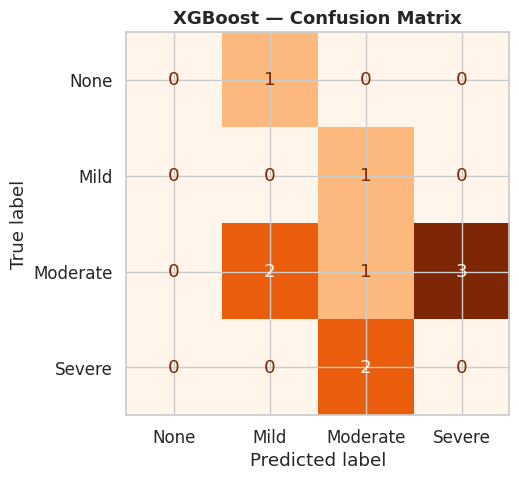

In [37]:
# XGBoost confusion matrix
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_preds),
    display_labels=SEV_ORDER).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

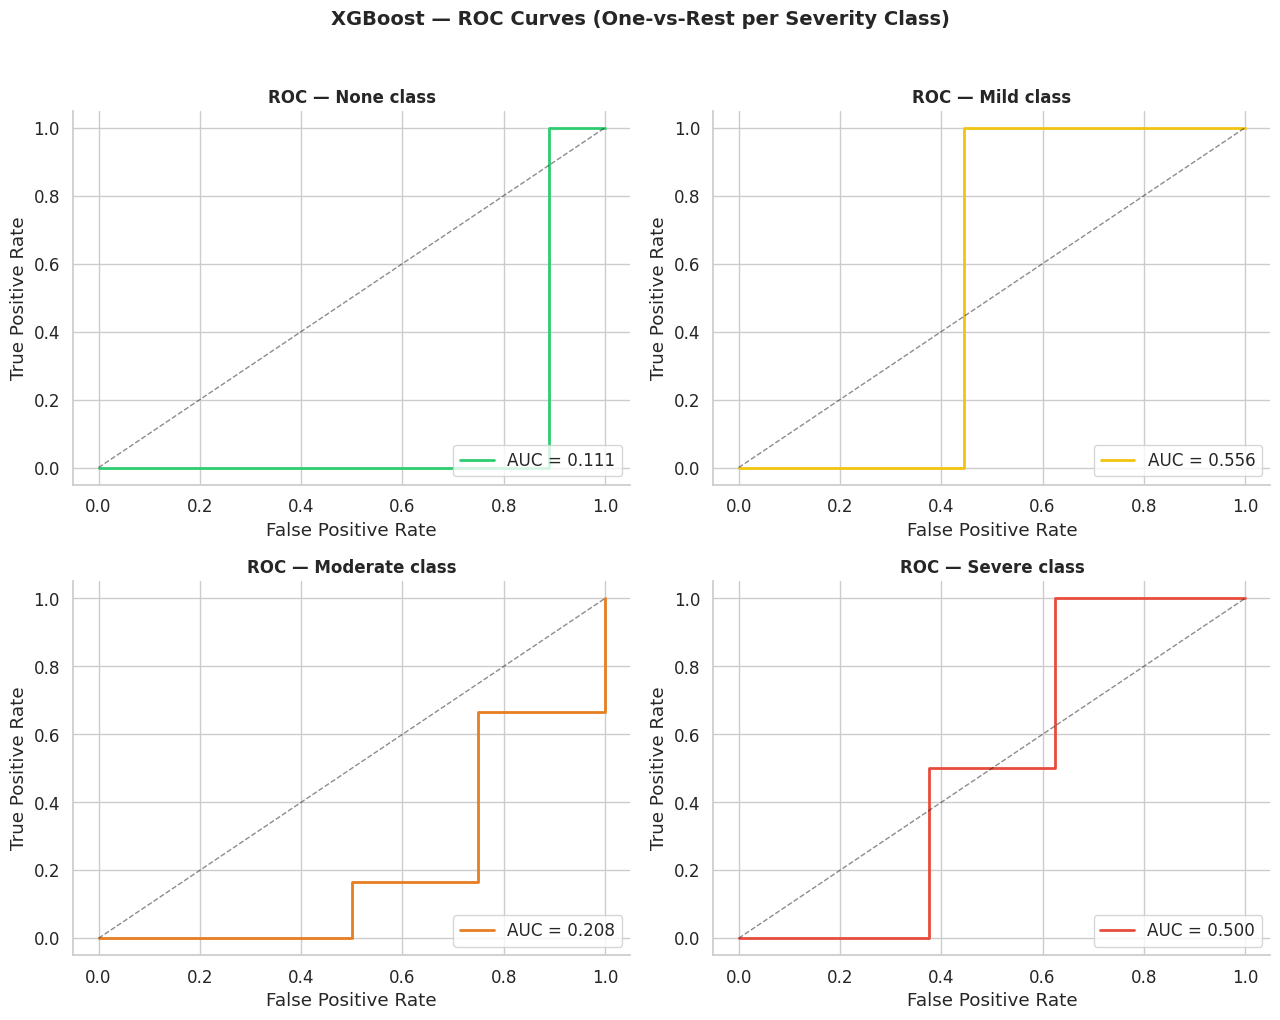

Overall macro ROC-AUC: 0.3438


In [38]:
# ── ROC-AUC curves for XGBoost (best model) — one per class ─────────────────
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (cls_idx, cls_name) in enumerate(SEV_MAP.items()):
    fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], xgb_proba[:, cls_idx])
    roc_auc_val = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color=SEV_COLORS[cls_idx], lw=2,
                 label=f'AUC = {roc_auc_val:.3f}')
    axes[i].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[i].set_title(f'ROC — {cls_name} class', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('XGBoost — ROC Curves (One-vs-Rest per Severity Class)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('xgb_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall macro ROC-AUC: {xgb_auc:.4f}')

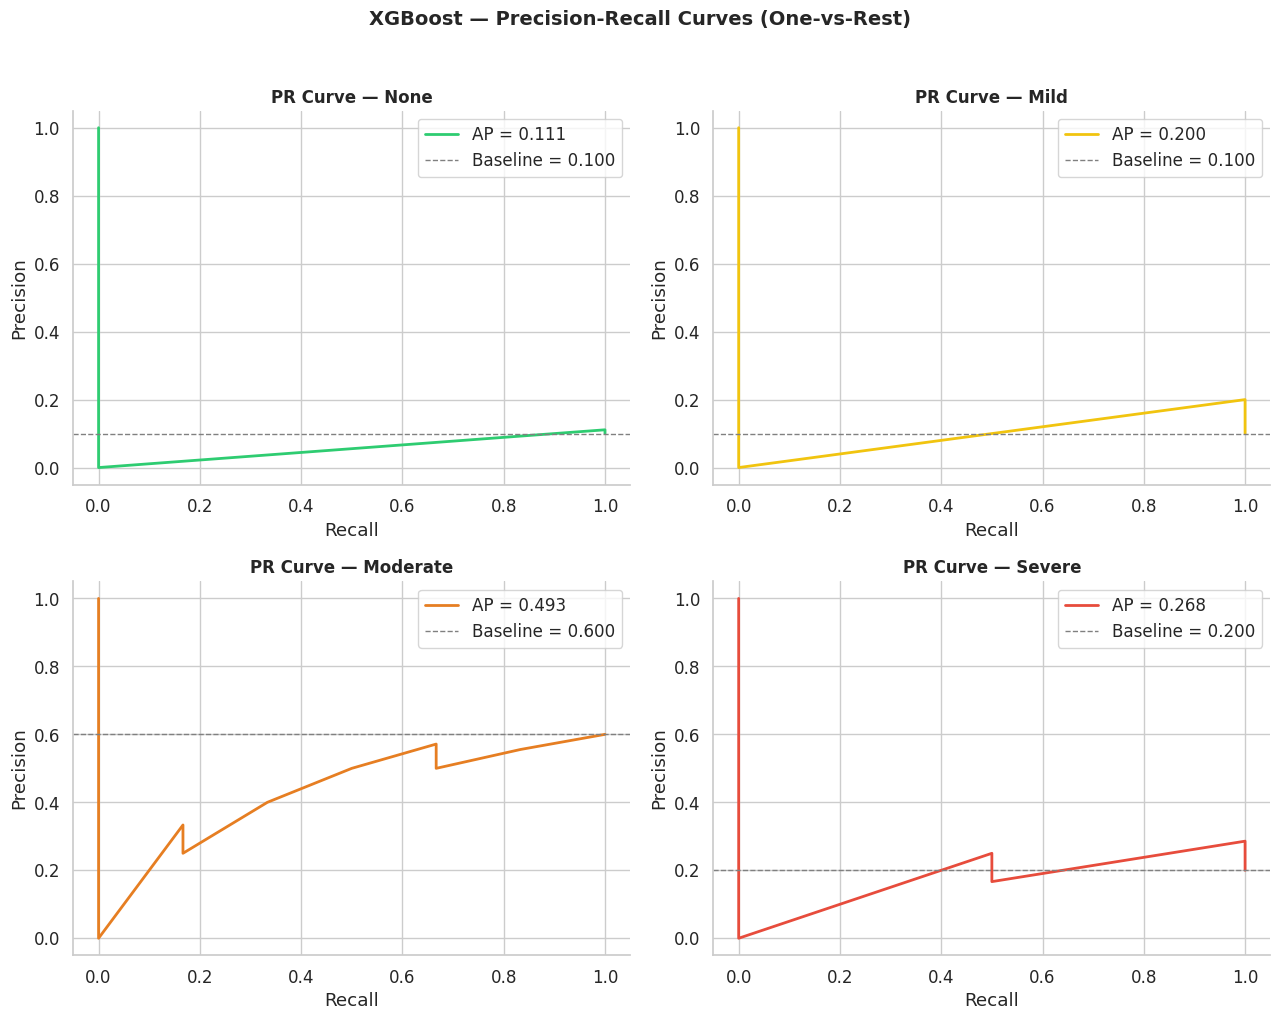

In [39]:
# ── Precision-Recall curves — XGBoost ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (cls_idx, cls_name) in enumerate(SEV_MAP.items()):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, cls_idx], xgb_proba[:, cls_idx])
    ap           = average_precision_score(y_test_bin[:, cls_idx], xgb_proba[:, cls_idx])
    baseline     = y_test_bin[:, cls_idx].mean()

    axes[i].plot(rec, prec, color=SEV_COLORS[cls_idx], lw=2,
                 label=f'AP = {ap:.3f}')
    axes[i].axhline(baseline, linestyle='--', color='gray', lw=1,
                    label=f'Baseline = {baseline:.3f}')
    axes[i].set_title(f'PR Curve — {cls_name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend()
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('XGBoost — Precision-Recall Curves (One-vs-Rest)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('xgb_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ── Stratified K-Fold Cross-Validation — all 3 models ────────────────────────
print('Running 5-fold cross-validation on all models...')
print('(Uses unsmoted training data for honest CV estimate)\n')

skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                      max_iter=1000, class_weight='balanced',
                                      random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        **grid_search.best_params_,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1)
}

cv_results = {}
for name, model in cv_models.items():
    cv = cross_validate(model, X_imp, y,
                        cv=skf_eval,
                        scoring=['f1_macro','roc_auc_ovr_weighted'],
                        n_jobs=-1)
    cv_results[name] = {
        'F1 Mean'   : cv['test_f1_macro'].mean(),
        'F1 Std'    : cv['test_f1_macro'].std(),
        'AUC Mean'  : cv['test_roc_auc_ovr_weighted'].mean(),
        'AUC Std'   : cv['test_roc_auc_ovr_weighted'].std(),
    }
    print(f'{name:22s} | F1: {cv_results[name]["F1 Mean"]:.4f} +/- {cv_results[name]["F1 Std"]:.4f} | AUC: {cv_results[name]["AUC Mean"]:.4f} +/- {cv_results[name]["AUC Std"]:.4f}')

cv_df = pd.DataFrame(cv_results).T.round(4)
print(f'\n5-Fold Cross-Validation Results:')
print(cv_df)

Running 5-fold cross-validation on all models...
(Uses unsmoted training data for honest CV estimate)

Logistic Regression    | F1: 0.2140 +/- 0.0880 | AUC: nan +/- nan
Random Forest          | F1: 0.1587 +/- 0.0168 | AUC: nan +/- nan
XGBoost                | F1: 0.1627 +/- 0.0744 | AUC: nan +/- nan

5-Fold Cross-Validation Results:
                     F1 Mean  F1 Std  AUC Mean  AUC Std
Logistic Regression   0.2140  0.0880       NaN      NaN
Random Forest         0.1587  0.0168       NaN      NaN
XGBoost               0.1627  0.0744       NaN      NaN


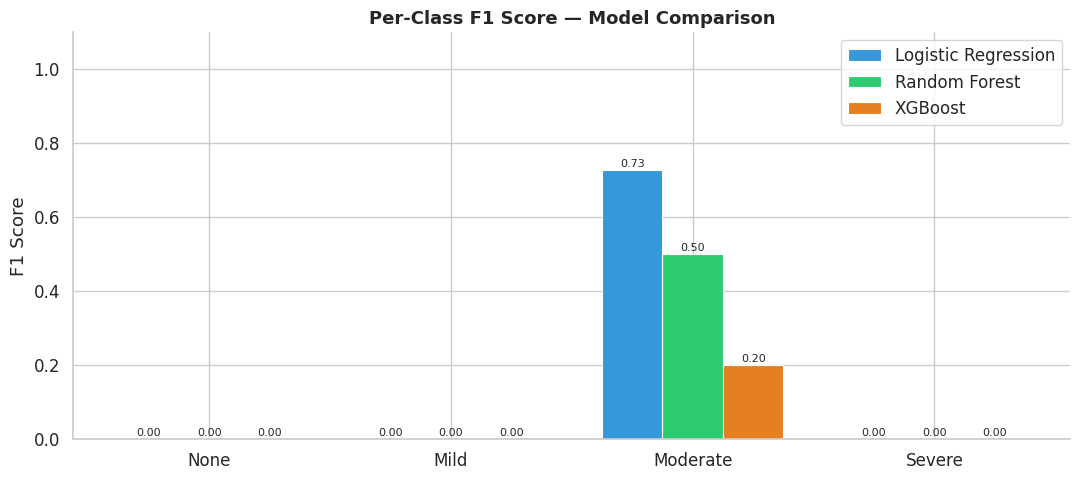

In [41]:
# ── Per-class F1 comparison bar chart ────────────────────────────────────────
from sklearn.metrics import classification_report

def get_per_class_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred,
                                    target_names=SEV_ORDER,
                                    output_dict=True)
    return {cls: report[cls]['f1-score'] for cls in SEV_ORDER if cls in report}

f1_data = {
    'Logistic Regression': get_per_class_f1(y_test, lr_preds),
    'Random Forest'       : get_per_class_f1(y_test, rf_preds),
    'XGBoost'             : get_per_class_f1(y_test, xgb_preds),
}
f1_plot = pd.DataFrame(f1_data).T

fig, ax = plt.subplots(figsize=(11,5))
x = np.arange(len(SEV_ORDER))
width = 0.25
for i, (model_name, color) in enumerate(zip(['Logistic Regression','Random Forest','XGBoost'],
                                             ['#3498db','#2ecc71','#e67e22'])):
    vals = [f1_data[model_name].get(cls,0) for cls in SEV_ORDER]
    bars = ax.bar(x + i*width, vals, width, label=model_name, color=color,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.2f}', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(SEV_ORDER)
ax.set_title('Per-Class F1 Score — Model Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
print('Computing SHAP values...')
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) for XGBoost multiclass
if isinstance(shap_values, list):
    # Older SHAP returns list of arrays, one per class
    print(f'SHAP format: list of {len(shap_values)} class arrays')
    shap_severe = shap_values[3]  # class 3 = Severe
    shap_all    = np.abs(np.stack(shap_values)).mean(axis=0)  # mean across classes
else:
    print(f'SHAP format: array of shape {shap_values.shape}')
    shap_severe = shap_values[:, :, 3]
    shap_all    = np.abs(shap_values).mean(axis=2)

print('SHAP values computed.')

Computing SHAP values...
SHAP format: array of shape (10, 31, 4)
SHAP values computed.


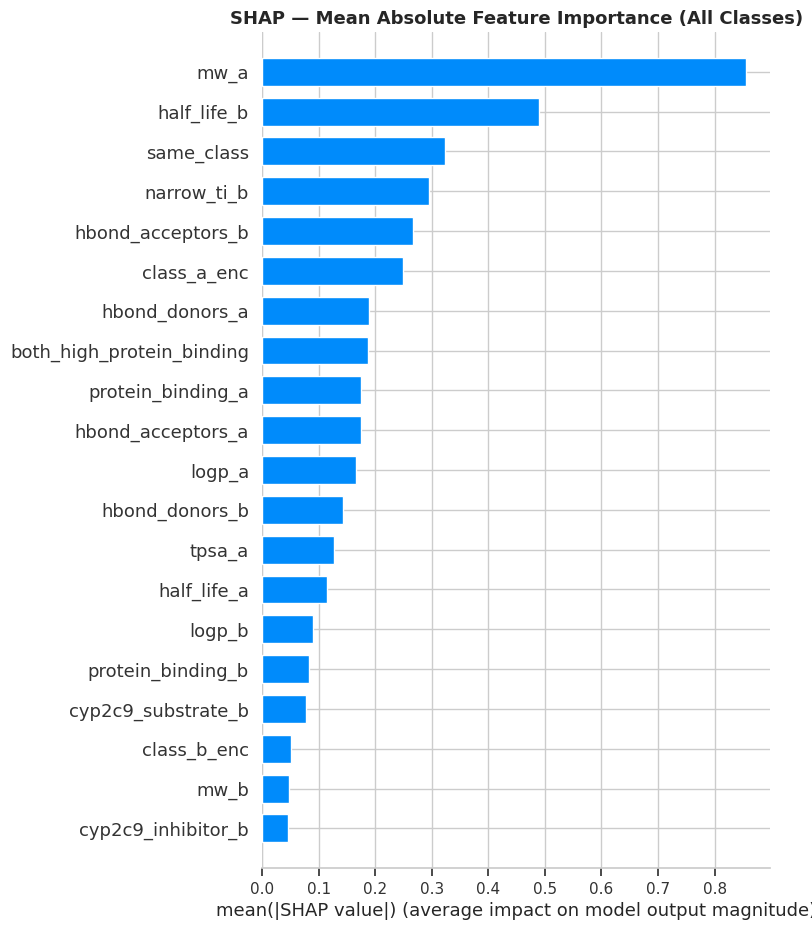

In [43]:
# Beeswarm plot — overall feature importance (mean |SHAP|)
shap.summary_plot(
    shap_all,
    pd.DataFrame(X_test, columns=FEATURE_COLS),
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP — Mean Absolute Feature Importance (All Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_all.png', dpi=150, bbox_inches='tight')
plt.show()

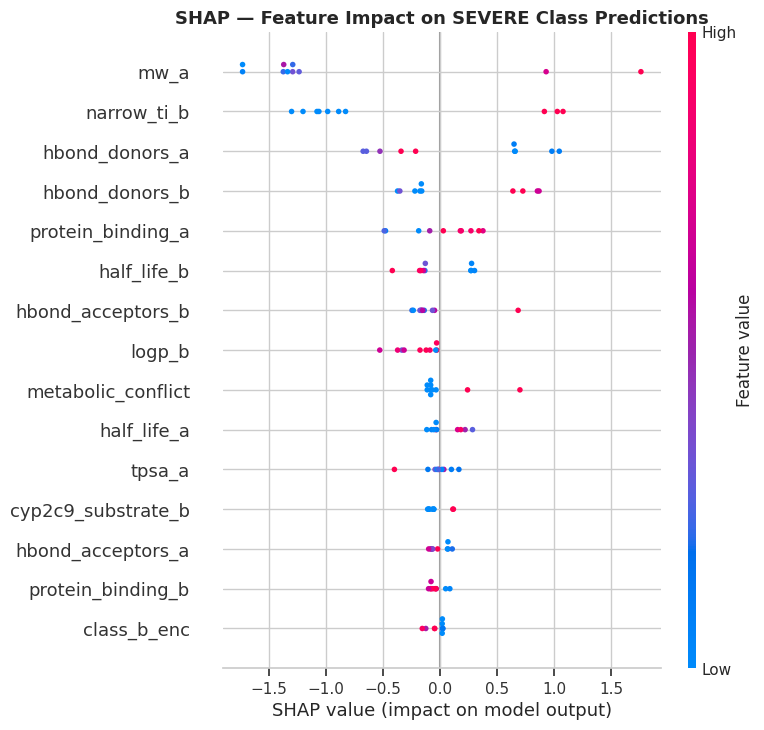

Red = pushes toward Severe, Blue = pushes away from Severe


In [44]:
# SHAP dot plot — SEVERE class only (most clinically important)
shap.summary_plot(
    shap_severe,
    pd.DataFrame(X_test, columns=FEATURE_COLS),
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP — Feature Impact on SEVERE Class Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dot_severe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red = pushes toward Severe, Blue = pushes away from Severe')

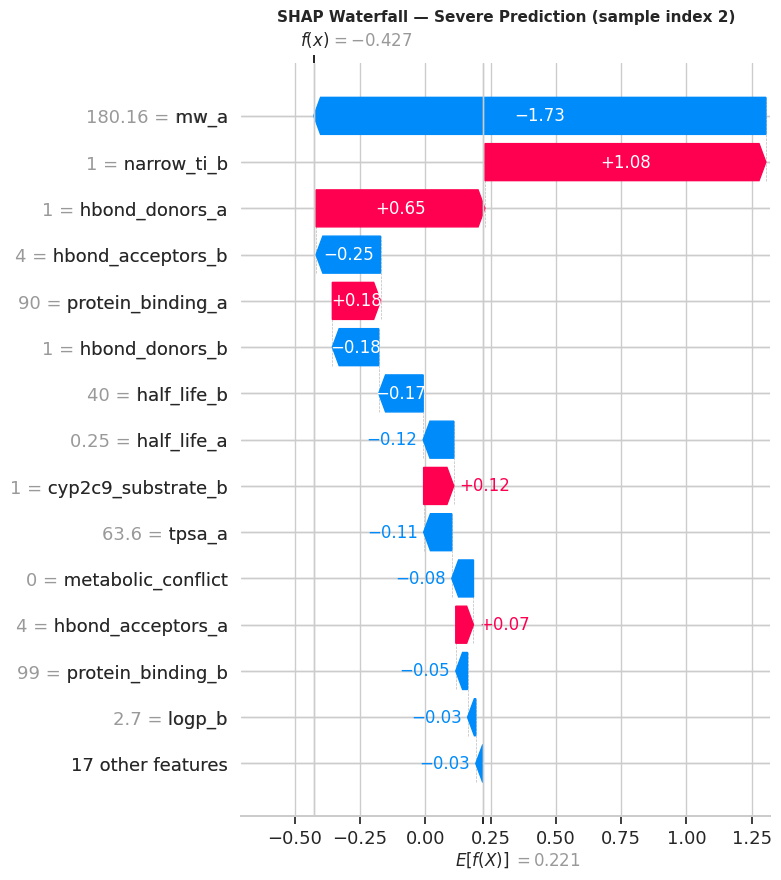

Drug pair predicted as SEVERE:
  Drug A : aspirin (Analgesics_NSAIDs)
  Drug B : warfarin (Anticoagulants)
  True severity : Severe
  Predicted     : Moderate


In [45]:
# Waterfall plot — explain a single severe prediction
severe_indices = np.where(y_test.values == 3)[0]

if len(severe_indices) > 0:
    idx = severe_indices[0]
    sample = pd.DataFrame(X_test.iloc[[idx]], columns=FEATURE_COLS)

    if isinstance(shap_values, list):
        sv_sample = shap_values[3][idx]
        exp = shap.Explanation(
            values=sv_sample,
            base_values=explainer.expected_value[3],
            data=sample.values[0],
            feature_names=FEATURE_COLS
        )
    else:
        sv_sample = shap_values[idx, :, 3]
        exp = shap.Explanation(
            values=sv_sample,
            base_values=explainer.expected_value[3],
            data=sample.values[0],
            feature_names=FEATURE_COLS
        )

    shap.waterfall_plot(exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Severe Prediction (sample index {idx})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_severe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Drug pair predicted as SEVERE:')
    orig_row = df.iloc[y_test.index[idx]]
    print(f'  Drug A : {orig_row.get("drug_a", "?")} ({orig_row.get("class_a", "?")})')
    print(f'  Drug B : {orig_row.get("drug_b", "?")} ({orig_row.get("class_b", "?")})')
    print(f'  True severity : {SEV_MAP[y_test.iloc[idx]]}')
    print(f'  Predicted     : {SEV_MAP[xgb_preds[idx]]}')
else:
    print('No severe cases in test set for waterfall plot.')

In [46]:
# Build leaderboard
leaderboard = pd.DataFrame([
    {
        'Model'         : 'Logistic Regression',
        'Macro F1'      : round(lr_f1, 4),
        'ROC-AUC'       : round(lr_auc, 4),
        'CV F1 Mean'    : round(cv_results['Logistic Regression']['F1 Mean'], 4),
        'CV F1 Std'     : round(cv_results['Logistic Regression']['F1 Std'], 4),
        'Role'          : 'Baseline'
    },
    {
        'Model'         : 'Random Forest',
        'Macro F1'      : round(rf_f1, 4),
        'ROC-AUC'       : round(rf_auc, 4),
        'CV F1 Mean'    : round(cv_results['Random Forest']['F1 Mean'], 4),
        'CV F1 Std'     : round(cv_results['Random Forest']['F1 Std'], 4),
        'Role'          : 'Ensemble'
    },
    {
        'Model'         : 'XGBoost (Tuned)',
        'Macro F1'      : round(xgb_f1, 4),
        'ROC-AUC'       : round(xgb_auc, 4),
        'CV F1 Mean'    : round(cv_results['XGBoost']['F1 Mean'], 4),
        'CV F1 Std'     : round(cv_results['XGBoost']['F1 Std'], 4),
        'Role'          : 'Primary ML Model'
    },
])

leaderboard = leaderboard.sort_values('Macro F1', ascending=False).reset_index(drop=True)
leaderboard.index += 1
print('='*70)
print('  MODEL LEADERBOARD')
print('='*70)
print(leaderboard.to_string())
print('='*70)

  MODEL LEADERBOARD
                 Model  Macro F1  ROC-AUC  CV F1 Mean  CV F1 Std              Role
1  Logistic Regression    0.1818   0.6146      0.2140     0.0880          Baseline
2        Random Forest    0.1250   0.3108      0.1587     0.0168          Ensemble
3      XGBoost (Tuned)    0.0500   0.3438      0.1627     0.0744  Primary ML Model


In [47]:
# Leaderboard bar chart
fig = go.Figure()
metrics = ['Macro F1','ROC-AUC','CV F1 Mean']
colors  = ['#3498db','#e67e22','#2ecc71']

for metric, color in zip(metrics, colors):
    fig.add_trace(go.Bar(
        name=metric,
        x=leaderboard['Model'],
        y=leaderboard[metric],
        marker_color=color,
        text=leaderboard[metric].round(4),
        textposition='outside'
    ))

fig.update_layout(
    barmode='group',
    title='Model Comparison Leaderboard — DDI Nigeria',
    yaxis=dict(title='Score', range=[0,1.1]),
    xaxis_title='Model',
    plot_bgcolor='white',
    height=480,
    legend=dict(orientation='h', y=1.05)
)
fig.show()

In [48]:
import os
MODELS_FOLDER = os.path.join(SAVE_FOLDER, 'models')
os.makedirs(MODELS_FOLDER, exist_ok=True)

# Save models
joblib.dump(lr_model,  os.path.join(MODELS_FOLDER, 'lr_model.pkl'))
joblib.dump(rf_model,  os.path.join(MODELS_FOLDER, 'rf_model.pkl'))
joblib.dump(xgb_model, os.path.join(MODELS_FOLDER, 'xgboost_best.pkl'))
joblib.dump(scaler,    os.path.join(MODELS_FOLDER, 'scaler.pkl'))
joblib.dump(imputer,   os.path.join(MODELS_FOLDER, 'imputer.pkl'))

# Save leaderboard
leaderboard.to_csv(os.path.join(SAVE_FOLDER, 'ml_leaderboard.csv'), index=False)

# Save feature list
pd.Series(FEATURE_COLS).to_csv(
    os.path.join(SAVE_FOLDER, 'feature_columns.csv'), index=False)

# Save SHAP values
import numpy as np
np.save(os.path.join(SAVE_FOLDER, 'shap_values_test.npy'),
        shap_all if not isinstance(shap_values, list) else np.stack(shap_values).mean(axis=0))

print('Saved to Google Drive:')
print(f'  {MODELS_FOLDER}/lr_model.pkl')
print(f'  {MODELS_FOLDER}/rf_model.pkl')
print(f'  {MODELS_FOLDER}/xgboost_best.pkl')
print(f'  {MODELS_FOLDER}/scaler.pkl')
print(f'  {MODELS_FOLDER}/imputer.pkl')
print(f'  {SAVE_FOLDER}/ml_leaderboard.csv')
print(f'  {SAVE_FOLDER}/feature_columns.csv')
print()
print('Next: open 03_lstm_notebook.ipynb')

Saved to Google Drive:
  /content/drive/MyDrive/DDI project /models/lr_model.pkl
  /content/drive/MyDrive/DDI project /models/rf_model.pkl
  /content/drive/MyDrive/DDI project /models/xgboost_best.pkl
  /content/drive/MyDrive/DDI project /models/scaler.pkl
  /content/drive/MyDrive/DDI project /models/imputer.pkl
  /content/drive/MyDrive/DDI project /ml_leaderboard.csv
  /content/drive/MyDrive/DDI project /feature_columns.csv

Next: open 03_lstm_notebook.ipynb
